<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/fits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FITS in Astronomy & Astrophysics**

In [ ]:
!pip install astropy photutils astroquery -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 912.9/912.9 kB 28.9 MB/s eta 0:00:00


Accessing data from the James Webb Space Telescope's (JWST) instruments, such as NIRCam and MIRI, through Astropy or Astroquery is possible, but not directly through the instruments themselves. You can retrieve the archival data associated with these instruments through the MAST (Mikulski Archive for Space Telescopes) interface provided by Astroquery.


In [ ]:
from astroquery.mast import Observations

# Set up the query parameters
obs_table = Observations.query_criteria(
    obs_collection='JWST',           # Specific to JWST
    instrument_name=['NIRCam', 'MIRI']  # Query both NIRCam and MIRI
)

# Display the results
print(obs_table)

intentType obs_collection provenance_name instrument_name ... mtFlag srcDen   obsid     objID  
---------- -------------- --------------- --------------- ... ------ ------ --------- ---------
   science           JWST         CALJWST            MIRI ...  False    nan 102604820 215004479


In [ ]:
# Assuming you've selected specific observations (first one for this example)
data_products = Observations.get_product_list(obs_table[0])

# Download the data
Observations.download_products(data_products)

In [ ]:
# Assuming you've selected specific observations (first one for this example)
data_products = Observations.get_product_list(obs_table[0])

# Download all data
#Observations.download_products(data_products)

# Show the available data products
print(data_products)

  obsID   obs_collection dataproduct_type ... dataRights calib_level filters
--------- -------------- ---------------- ... ---------- ----------- -------
 87595990           JWST            image ...     PUBLIC           1   P750L
 87595990           JWST            image ...     PUBLIC           1   P750L
 87595990           JWST            image ...     PUBLIC           1   P750L
 87595990           JWST            image ...     PUBLIC           1   P750L
 87595990           JWST            image ...     PUBLIC           1   P750L
 87595990           JWST            image ...     PUBLIC           1   P750L
 87595990           JWST            image ...     PUBLIC           1   P750L
 87595990           JWST            image ...     PUBLIC           1   P750L
 87595990           JWST            image ...     PUBLIC           1   P750L
 87595990           JWST            image ...     PUBLIC           1   P750L
      ...            ...              ... ...        ...         ...     ...

In [ ]:
# Select the first few products to download (e.g., first 5 products)
selected_products = data_products[:5]  # Adjust the number as needed

# Download the selected data products
Observations.download_products(selected_products)

Local Path,Status,Message,URL
str102,str8,object,object
./mastDownload/JWST/jw01529004001_02101_00001_mirimage/jw01529004001_gs-acq1_2022191064946_stream.fits,COMPLETE,None,None
./mastDownload/JWST/jw01529004001_02101_00001_mirimage/jw01529004001_gs-acq1_2022191064946_uncal.fits,COMPLETE,None,None
./mastDownload/JWST/jw01529004001_02101_00001_mirimage/jw01529004001_gs-acq2_2022191064947_stream.fits,COMPLETE,None,None
./mastDownload/JWST/jw01529004001_02101_00001_mirimage/jw01529004001_gs-acq2_2022191064947_uncal.fits,COMPLETE,None,None
./mastDownload/JWST/jw01529004001_02101_00001_mirimage/jw01529004001_gs-fg_2022191070903_stream.fits,COMPLETE,None,None


In [ ]:
# Inspect data

from astropy.io import fits

# Load the FITS file
file_path = './mastDownload/JWST/jw01529004001_02101_00001_mirimage/jw01529004001_gs-acq1_2022191064946_stream.fits'
hdul = fits.open(file_path)

# Inspect the structure of the FITS file (HDU List)
hdul.info()

Filename: ./mastDownload/JWST/jw01529004001_02101_00001_mirimage/jw01529004001_gs-acq1_2022191064946_stream.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     106   ()      
  1  SCI           1 ImageHDU        32   (128, 128, 12)   int16 (rescales to uint16)   


**HDUs (Header Data Units):** Each line after this represents an **HDU**, which can either store image data, tables, or other types of information.

HDU 0: **PRIMARY (Primary Header Data Unit)**
```
  0  PRIMARY       1 PrimaryHDU     106   ()  
```
This contains **only metadata** (i.e., it has no image data) and is mainly used to store details about the observation and the instrument (like exposure time, filters used, etc.).
- **HDU index**: `0`
- **Name**: `PRIMARY`
- **Version**: `1` (often the default version number)
- **Type**: `PrimaryHDU` indicates that this is the primary header unit. FITS files always have one primary HDU, and it might not contain image data (it could be empty).
- **Cards**: `106` This tells you that the primary header has **106 metadata entries (cards)**, which store information about the observation, the instrument, and the data. You can inspect this header using `hdul[0].header` to see all the specific metadata fields.
- **Dimensions**: `()` This means that the **PRIMARY HDU does not contain any image data**, as it has no dimensions (i.e., it is empty). It only contains metadata in the header.

HDU 1: **SCI (Science Data)**
```
  1  SCI           1 ImageHDU        32   (128, 128, 12)   int16 (rescales to uint16)
```
- This is where the actual **science data** (likely an image) is stored.
   - The data has dimensions of **128 x 128 pixels**, with **12 layers** (this could be different time steps, different wavelength channels, etc.).
   - The pixel values are stored as 16-bit integers (`int16`), and there may be a scaling factor applied to convert them into physical units (such as flux).
- **HDU index**: `1`
- **Name**: `SCI`
- **Version**: `1`
- **Type**: `ImageHDU` indicates that this HDU contains image data.
- **Cards**: `32` This tells you that the header associated with this HDU contains **32 metadata entries (cards)**. You can inspect this header with `hdul[1].header`.
- **Dimensions**: `(128, 128, 12)` This is the shape of the data stored in this HDU. It represents a **3D array** with:
  - `128 x 128` pixels in the first two dimensions (likely the image size),
  - `12` slices in the third dimension (this could represent different exposures, time steps, or wavelength channels, depending on the observation).
- **Format**: `int16 (rescales to uint16)` This tells you the data type of the pixel values in this image is **16-bit signed integers (int16)**, but they can be rescaled to unsigned integers (uint16). The rescaling often involves applying scaling factors that are stored in the header (e.g., `BSCALE` and `BZERO` values in the header).

You can view the metadata for both HDUs using hdul[0].header and hdul[1].header. These headers will provide detailed information about the observation, including the instrument setup, exposure time, target, and more:

In [ ]:
print(repr(hdul[0].header))  # Primary HDU header

SIMPLE  =                    T / Data conform to FITS standard                  
BITPIX  =                    8 / bits per data value                            
NAXIS   =                    0 / Number of axes                                 
EXTEND  =                    T / file may contain standard extensions           
NEXTEND =                    1 / Number of file extensions                      
DATE    = '2022-07-10T18:31:08' / UTC date file created                         
ORIGIN  = 'STSCI   '           / institution responsible for creating FITS file 
TIMESYS = 'UTC     '           / principal time system for time-related keywords
TIMEUNIT= 's       '           / Default unit applicable to all time values     
FILENAME= 'jw01529004001_gs-acq1_2022191064946_stream.fits' / Name of the file  
SDP_VER = '2022_2a '           / data processing software version number        
PRD_VER = 'PRDOPSSOC-055'      / S&OC PRD version number used in data processing
OSS_VER = '008.004.011.000' 

In [ ]:
print(repr(hdul[1].header))  # Science data HDU header

XTENSION= 'IMAGE   '           / FITS extension type                            
BITPIX  =                   16 / bits per data value                            
NAXIS   =                    3 / Number of axes                                 
NAXIS1  =                  128 / Size of the axis                               
NAXIS2  =                  128 / Size of the axis                               
NAXIS3  =                   12 / Size of the axis                               
PCOUNT  =                    0 / number of parameter bytes following data table 
GCOUNT  =                    1 / number of groups                               
BSCALE  =                  1.0 / scale factor for array value to physical value 
BZERO   =                32768 / physical value for an array value of zero      
BUNIT   = 'DN      '           / physical units of the data array values        
EXTNAME = 'SCI     '           / EXTNAME of the extension containing image      
RADESYS = 'ICRS    '        

Explore the science data: If you want to look at the actual data, you can access it via hdul[1].data, which will give you the 3D array of shape (128, 128, 12). To explore or visualize this data, you can slice it and plot it using libraries like matplotlib.

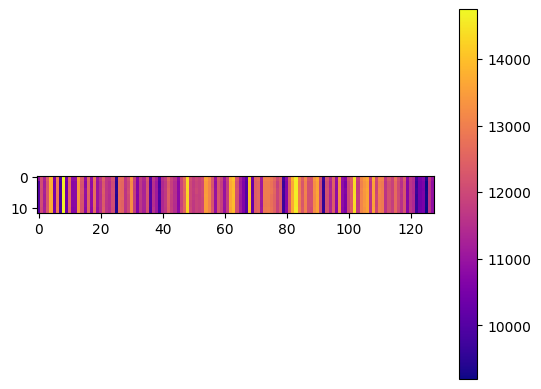

In [ ]:
import matplotlib.pyplot as plt

# Plot the first image slice (for the first layer in the 3rd dimension)
plt.imshow(hdul[1].data[:, :, 0], cmap='plasma')
plt.colorbar()
plt.show()

In [ ]:
# Access the primary header
primary_header = hdul[0].header
print(repr(primary_header))  # View primary header contents

SIMPLE  =                    T / Data conform to FITS standard                  
BITPIX  =                    8 / bits per data value                            
NAXIS   =                    0 / Number of axes                                 
EXTEND  =                    T / file may contain standard extensions           
NEXTEND =                    1 / Number of file extensions                      
DATE    = '2022-07-10T18:31:08' / UTC date file created                         
ORIGIN  = 'STSCI   '           / institution responsible for creating FITS file 
TIMESYS = 'UTC     '           / principal time system for time-related keywords
TIMEUNIT= 's       '           / Default unit applicable to all time values     
FILENAME= 'jw01529004001_gs-acq1_2022191064946_stream.fits' / Name of the file  
SDP_VER = '2022_2a '           / data processing software version number        
PRD_VER = 'PRDOPSSOC-055'      / S&OC PRD version number used in data processing
OSS_VER = '008.004.011.000' 

In [ ]:
# Access the primary data (if available)
primary_data = hdul[0].data
print(primary_data)  # Will print the data array if it exists (might be large)

None


In [ ]:
# If there are more extensions, you can explore them:
# Example: access extension 1's header and data
if len(hdul) > 1:
    extension_header = hdul[1].header
    print(repr(extension_header))

    extension_data = hdul[1].data
    print(extension_data)

XTENSION= 'IMAGE   '           / FITS extension type                            
BITPIX  =                   16 / bits per data value                            
NAXIS   =                    3 / Number of axes                                 
NAXIS1  =                  128 / Size of the axis                               
NAXIS2  =                  128 / Size of the axis                               
NAXIS3  =                   12 / Size of the axis                               
PCOUNT  =                    0 / number of parameter bytes following data table 
GCOUNT  =                    1 / number of groups                               
BSCALE  =                  1.0 / scale factor for array value to physical value 
BZERO   =                32768 / physical value for an array value of zero      
BUNIT   = 'DN      '           / physical units of the data array values        
EXTNAME = 'SCI     '           / EXTNAME of the extension containing image      
RADESYS = 'ICRS    '        

In [ ]:
# Close the FITS file when done
hdul.close()